# HAM10000 Skin Lesion Classification
### Transfer Learning Project

---

## Project Overview
* **Dataset:** HAM10000 (*Human Against Machine with 10000 training images*) | Kaggle: Skin Cancer MNIST
* **Task:** Multi-class Classification — 7 types of skin lesions
* **Input:** Dermoscopy JPEG images (original + 28x28 / 8x8 pixel versions)
* **Output:** Probability distribution over 7 classes (softmax output)
* **License:** CC BY-NC-SA 4.0

---

## Dataset Structure
Based on the Kaggle data panel, the working directory is organized as follows:

```text
├── HAM10000_images_part_1/    # JPEG dermoscopy images (part 1)
├── HAM10000_images_part_2/    # JPEG dermoscopy images (part 2)
├── HAM10000_metadata.csv      # Labels + patient info (Primary label file)
├── hmnist_28_28_RGB.csv       # Flattened 28×28 RGB pixel arrays (optional)
├── hmnist_28_28_L.csv         # Flattened 28×28 grayscale pixel arrays
├── hmnist_8_8_RGB.csv         # Flattened 8×8 RGB (very low-res, EDA use only)
└── hmnist_8_8_L.csv           # Flattened 8×8 grayscale

##  0. Dependencies & Environment Setup

Before getting started, ensure all required packages are installed in your environment. You can install them via pip:

```bash
pip install torch torchvision timm pandas numpy matplotlib seaborn scikit-learn pillow tqdm

In [ ]:
import os, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as T
import timm

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from sklearn.preprocessing import label_binarize

warnings.filterwarnings("ignore")
  
  


##  1. Configuration & Reproducibility

To ensure our experiments are fully reproducible (Requirement 10), we need to lock the random seeds across all libraries (Python, NumPy, and PyTorch). We also configure the hardware device to utilize GPU acceleration if it's available.



In [ ]:
SEED = 42


def seed_everything(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


seed_everything()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[INFO] Using device: {DEVICE}")

##  2. Global Configuration (Req #10)

To maintain a clean and highly reproducible workflow, we define a master configuration dictionary (`CFG`). Centralizing these variables makes it easy to adjust paths, tweak hyperparameters, and toggle between different experimental setups without hunting through the code.

**Key Components of this Configuration:**
* **Class Mapping:** Defines the 7 skin lesion categories (e.g., Melanoma, Basal cell carcinoma) and maps them to numerical indices.
* **File Management:** Stores Kaggle directory paths for the split image folders and metadata CSVs.
* **Dataset Splits:** Sets aside 15% of the data for validation and 10% for testing.
* **Experiment Tracking:** Separates hyperparameters into distinct profiles:
    * **Baseline Model:** Lightweight setup using `EfficientNet-B0`.
    * **Improved Model:** Heavier `EfficientNet-B3` with label smoothing and a lower learning rate.
    * **Hyperparameter Sweep:** A predefined grid of learning rates and batch sizes to test model sensitivity (Req #5).


In [ ]:



# 2.  CONFIGURATION — Req #10
# HAM10000 has 7 diagnostic categories:
HAM_CLASSES = {
    "nv"   : 0,   # Melanocytic nevi (benign, dominant class ~67%)
    "mel"  : 1,   # Melanoma (malignant)
    "bkl"  : 2,   # Benign keratosis-like lesions
    "bcc"  : 3,   # Basal cell carcinoma
    "akiec": 4,   # Actinic keratoses / Bowen's disease
    "vasc" : 5,   # Vascular lesions
    "df"   : 6,   # Dermatofibroma
}
CLASS_NAMES = list(HAM_CLASSES.keys())   # index → name
NUM_CLASSES = len(HAM_CLASSES)           # 7

CFG = dict(
    # ── Paths (adjust to your Kaggle environment) ─────────────────────────
    # Images live in two folders; we search both for each image_id
    IMG_DIR_1    = "/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1",
    IMG_DIR_2    = "/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_2",
    LABEL_CSV    = "/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_metadata.csv",

    # Optional: pre-flattened pixel CSVs (used only for EDA visualisation)
    PIXEL_CSV_28 = "/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/hmnist_28_28_L.csv",

    # Subset for quick testing (set None for full 10,015 images)
    SUBSET       = None,

    # Split ratios
    VAL_SPLIT    = 0.15,
    TEST_SPLIT   = 0.10,

    # Image size fed to EfficientNet
    IMG_SIZE     = 224,

    # ── Baseline training 
    BASELINE = dict(
        model_name   = "efficientnet_b0",
        epochs       = 15,
        lr           = 1e-3,
        batch_size   = 64,
        weight_decay = 1e-4,
        scheduler    = "cosine",
        label_smooth = 0.0,
    ),

    # ── Improved training
    IMPROVED = dict(
        model_name   = "efficientnet_b3",
        epochs       = 20,
        lr           = 3e-4,
        batch_size   = 32,
        weight_decay = 1e-4,
        scheduler    = "cosine",
        label_smooth = 0.1,
    ),

    # ── Hyperparameter sweep (Req #5) 
    HP_SWEEP = [
        dict(lr=1e-2,  batch_size=64,  tag="LR=1e-2_BS=64"),
        dict(lr=1e-3,  batch_size=64,  tag="LR=1e-3_BS=64"),
        dict(lr=1e-4,  batch_size=64,  tag="LR=1e-4_BS=64"),
        dict(lr=1e-3,  batch_size=16,  tag="LR=1e-3_BS=16"),
        dict(lr=1e-3,  batch_size=128, tag="LR=1e-3_BS=128"),
    ],
    HP_SWEEP_EPOCHS = 5,
)



##  3. Problem Formulation (Req #1)

Before diving into the code, it is essential to formally define the machine learning task and understand how it differs from previous binary classification projects.

### Task Definition

- **Task:** Multi-class Image Classification
- **Input Space ($X$):** $224 \times 224 \times 3$ RGB dermoscopy image tensors (ImageNet normalized)
- **Output Space ($Y$):** $\{0, 1, 2, 3, 4, 5, 6\}$ — representing one of the 7 diagnostic categories
- **Learned Function ($f$):** $f: X \rightarrow \mathbb{R}^7$ (class logits) $\rightarrow$ Softmax $\rightarrow$ Probability Vector
- **Objective / Loss:** Cross-Entropy Loss (with optional label smoothing)
- **Evaluation Metrics:** Accuracy, Macro-AUC (One-vs-Rest), Per-class F1-Score, and Confusion Matrix

### Dataset Characteristics (HAM10000)

- **Size:** 10,015 dermoscopy images distributed across 7 categories.
- **Imbalance:** The dataset suffers from severe class imbalance. Melanocytic nevi (`nv`) make up approximately 67% of all samples.
- **Complexity:** Patient-level de-duplication is necessary, as the same lesion may have been photographed multiple times.
- **Metadata:** The dataset includes rich patient demographics (age, sex, localization) and confirmation methods (e.g., histopathology).

    **Key Changes vs. ISIC 2024 (Binary Classification):**

- **Architecture:** Transitioning from a single sigmoid output to a 7-neuron softmax head.
- **Loss Function:** Replacing `BCEWithLogitsLoss` with `CrossEntropyLoss`.
- **Metrics:** Shifting from standard Binary AUC to Macro OvR (One-vs-Rest) AUC to account for multiple classes.
- **Data Handling:** Moving from a single directory of 401k images to a smaller dataset of 10,015 images split across two distinct folders.

---

## 4. Data Understanding & Loading (Req #8)

In this phase, we build our data pipeline to ingest, clean, and visualize the HAM10000 dataset. Because the target labels are provided as strings (e.g., `'nv'`, `'mel'`, `'bkl'`), our first step is to encode them into integer indices using our predefined `HAM_CLASSES` mapping.

**The data loading pipeline performs the following critical steps:**

1. **Label Encoding:** Maps string diagnoses to numerical targets for PyTorch compatibility.
2. **Path Resolution:** Scans both fragmented image directories (`part_1` and `part_2`) to reconstruct the absolute file path for every `image_id`.
3. **Data Cleaning:** Identifies and drops any rows with missing images to prevent runtime crashes.
4. **Subsetting:** Optionally subsets the dataset for rapid testing and pipeline validation.
5. **Exploratory Data Analysis (EDA):** Generates visualizations to summarize the demographic and clinical distributions, including:
    - **Class Distribution:** Highlighting the severe class imbalance.
    - **Sex Distribution:** A breakdown of male vs. female patients.
    - **Age Distribution:** A histogram showing the age frequency of the patient pool.


In [ ]:


# 3.  PROBLEM FORMULATION — Req #1


# 4.  DATA UNDERSTANDING & LOADING — Req #8
def load_dataframe(cfg: dict) -> pd.DataFrame:
    
    df = pd.read_csv(cfg["LABEL_CSV"])

    # ── Map string label → integer class index 
    # Column name in HAM10000_metadata.csv is 'dx'
    df["target"] = df["dx"].map(HAM_CLASSES)

    # ── Resolve image path (images split across two folders) 
    def find_image(image_id):
        for folder in [cfg["IMG_DIR_1"], cfg["IMG_DIR_2"]]:
            p = os.path.join(folder, f"{image_id}.jpg")
            if os.path.exists(p):
                return p
        return None   # missing image → will be dropped below

    df["img_path"] = df["image_id"].apply(find_image)
    missing = df["img_path"].isna().sum()
    if missing:
        print(f"  [WARN] {missing} images not found — dropping those rows.")
        df.dropna(subset=["img_path"], inplace=True)

    # ── Optional subset 
    if cfg["SUBSET"]:
        df, _ = train_test_split(
            df, train_size=cfg["SUBSET"], stratify=df["target"], random_state=SEED
        )
        df.reset_index(drop=True, inplace=True)

    # ── Print summary 
    print("\n" + "="*60)
    print("DATASET SUMMARY — HAM10000")
    print("="*60)
    print(f"  Total samples  : {len(df):,}")
    vc = df["dx"].value_counts()
    for cls, count in vc.items():
        print(f"  {cls:8s} : {count:5,}  ({100*count/len(df):.1f}%)")

    # ── Visualisations 
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle("HAM10000 — Data Distribution (Req #8)", fontsize=13, fontweight="bold")

    # Class distribution
    colors_7 = ["#42A5F5","#EF5350","#66BB6A","#FFA726","#AB47BC","#26C6DA","#EC407A"]
    axes[0].bar(vc.index, vc.values, color=colors_7, edgecolor="black")
    axes[0].set_title("Class Distribution", fontweight="bold")
    axes[0].set_ylabel("Count")
    axes[0].tick_params(axis="x", rotation=30)
    for i, v in enumerate(vc.values):
        axes[0].text(i, v + 20, str(v), ha="center", fontsize=8, fontweight="bold")

    # Sex distribution
    if "sex" in df.columns:
        sex_counts = df["sex"].value_counts()
        axes[1].pie(sex_counts, labels=sex_counts.index, autopct="%1.1f%%",
                    colors=["#42A5F5","#EC407A","#B0BEC5"])
        axes[1].set_title("Sex Distribution", fontweight="bold")

    # Age distribution
    if "age" in df.columns:
        df["age"].dropna().hist(ax=axes[2], bins=20, color="#66BB6A", edgecolor="black")
        axes[2].set_title("Age Distribution", fontweight="bold")
        axes[2].set_xlabel("Age"); axes[2].set_ylabel("Count")

    plt.tight_layout()
    plt.savefig("data_distribution.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("  [Saved] data_distribution.png")

    # ── Sample images grid 
    _show_sample_images(df, cfg)

    return df



###  Sample Image Visualization
As the final step of our Exploratory Data Analysis, we generate a visual grid of sample dermoscopy images directly from the dataset. 
* The visualization creates a grid with one row dedicated to each of the 7 diagnostic classes.
* It randomly samples a few images per class to provide a clear visual intuition of the varying lesion types and shapes.
* The output is saved locally as a high-resolution image (`sample_images.png`) for easy inclusion in reports.

---

##  5. Dataset Class Setup (Req #8)

To efficiently feed our images into a PyTorch model, we define a custom `HAMDataset` class that inherits from `torch.utils.data.Dataset`. This class acts as the critical bridge between our metadata dataframe and the deep learning data loaders.

**Key Features & Handling:**
* **Pre-Resolved Paths:** In previous binary datasets (like ISIC 2024), images often lived in a single folder. Because HAM10000 images are split across `part_1` and `part_2`, our dataset class bypasses path-building logic by strictly utilizing the absolute paths we mapped into the `img_path` column during the data loading phase.
* **Multi-Class Labels:** It correctly extracts the integer labels ranging from 0 to 6 representing our specific lesion categories.
* **On-the-Fly Processing:** During training and inference, the class uses `PIL` to open the images, enforces an RGB color space, and dynamically applies necessary PyTorch transformations (such as resizing, augmentations, and ImageNet normalization) as the data is loaded into batches.

In [ ]:



def _show_sample_images(df: pd.DataFrame, cfg: dict, n_per_class: int = 3):
    """Display a grid of sample images — one row per class."""
    fig, axes = plt.subplots(NUM_CLASSES, n_per_class,
                             figsize=(n_per_class * 3, NUM_CLASSES * 3))
    fig.suptitle("Sample Dermoscopy Images per Class (Req #8)",
                 fontsize=13, fontweight="bold")

    for r, (cls_name, cls_idx) in enumerate(HAM_CLASSES.items()):
        subset = df[df["target"] == cls_idx].sample(
            min(n_per_class, (df["target"] == cls_idx).sum()), random_state=SEED
        )
        for c, (_, row) in enumerate(subset.iterrows()):
            img = Image.open(row["img_path"]).convert("RGB")
            axes[r, c].imshow(img)
            axes[r, c].set_title(f"{cls_name}\n(class {cls_idx})", fontsize=8)
            axes[r, c].axis("off")
        # blank any unused columns
        for c in range(len(subset), n_per_class):
            axes[r, c].axis("off")

    plt.tight_layout()
    plt.savefig("sample_images.png", dpi=120, bbox_inches="tight")
    plt.show()
    print("  [Saved] sample_images.png")


# 5.  DATASET CLASS — Req #8
class HAMDataset(Dataset):
    
    def __init__(self, df: pd.DataFrame, transform=None):
        self.df        = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        label = int(row["target"])                      # 0-6
        img   = Image.open(row["img_path"]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label




##  6. Image Augmentation & Transforms (Req #8)

To prevent our model from memorizing the training data and to improve its ability to generalize to unseen skin lesions, we apply a robust set of data augmentations using `torchvision.transforms`. 

**Transformation Strategy:**
* **Standardization:** All images are normalized using standard ImageNet mean and standard deviation values.
* **Spatial Augmentations:** During training, images are resized slightly larger than the target, randomly cropped back down to 224x224, flipped (horizontally and vertically), and randomly rotated. This simulates the varying angles and distances at which a dermatologist might examine a lesion.
* **Color Jitter:** Because the color of a lesion is a critical diagnostic feature, we apply moderate random changes to brightness, contrast, saturation, and hue. This forces the model to learn structural and textural features rather than relying solely on exact pixel colors.
* **Random Erasing:** We randomly mask out small patches of the training images to simulate occlusions (like hair or ruler marks) and force the network to look at the entire lesion rather than just one defining spot.

*(Note: The validation and test sets only receive standard resizing and normalization to ensure evaluation remains objective).*

---

## 7. Data Splitting & Data Loaders

Preparing the data loaders requires carefully navigating two major pitfalls in the HAM10000 dataset: **Data Leakage** and **Class Imbalance**.

### 1. Patient-Aware Splitting (Preventing Leakage)
Unlike simpler datasets, HAM10000 often contains multiple photographs of the *exact same lesion* (e.g., taken at different magnifications or angles). 
* **The Problem:** If we perform a naive, random row-level split, images of the exact same lesion might end up in both the training and test sets, falsely inflating our evaluation metrics.
* **The Solution:** We group the data by `lesion_id` and perform our Train/Val/Test split at the **lesion level**. This guarantees that if a lesion is used for training, no images of that specific lesion will ever appear in the validation or test sets. 

### 2. Handling the 7-Class Imbalance
As seen in our EDA, the dataset is heavily skewed (benign nevi make up ~67% of the data). To prevent the model from blindly predicting the majority class, we utilize PyTorch's `WeightedRandomSampler`.
* We calculate the frequency of each of the 7 classes in the training set.
* We assign an inverse weight to each sample based on its class frequency.
* During training, the DataLoader samples minority classes more frequently and majority classes less frequently, effectively simulating a perfectly balanced dataset for the model to learn from.

![Multimodal Data-2026-05-03-144351.png](<attachment:Multimodal Data-2026-05-03-144351.png>)
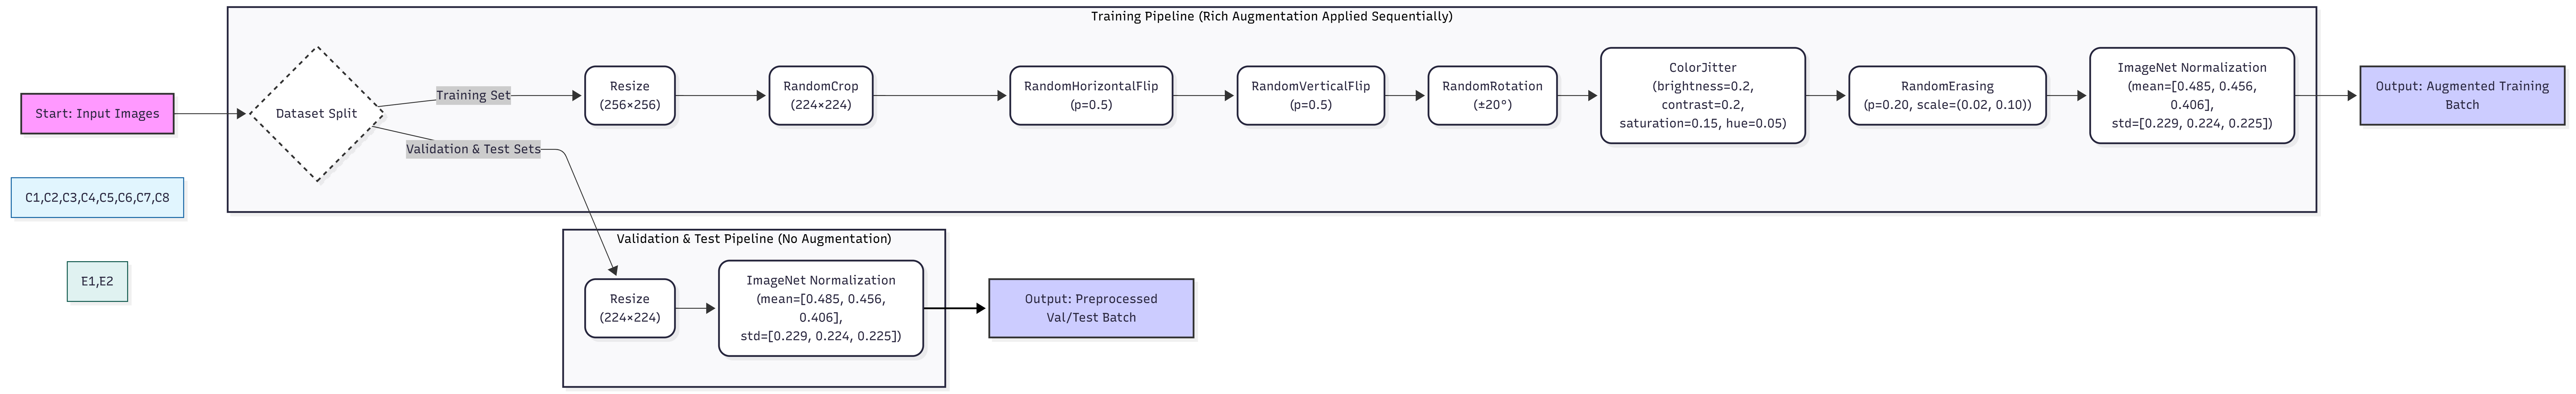

In [ ]:



# 6.  TRANSFORMS — Req #8
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

def get_transforms(img_size: int, mode: str = "train"):
    
    if mode == "train":
        return T.Compose([
            T.Resize((img_size + 32, img_size + 32)),
            T.RandomCrop(img_size),
            T.RandomHorizontalFlip(p=0.5),
            T.RandomVerticalFlip(p=0.5),
            T.RandomRotation(degrees=20),
            T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.15, hue=0.05),
            T.ToTensor(),
            T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
            T.RandomErasing(p=0.20, scale=(0.02, 0.10)),
        ])
    else:
        return T.Compose([
            T.Resize((img_size, img_size)),
            T.ToTensor(),
            T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ])


# 7.  DATA SPLITTING & LOADERS
def build_loaders(df: pd.DataFrame, cfg: dict, model_cfg: dict):
    
    # ── Lesion-level split 
    if "lesion_id" in df.columns:
        lesion_df = df.drop_duplicates("lesion_id")[["lesion_id", "target"]]
        tr_val_l, test_l = train_test_split(
            lesion_df, test_size=cfg["TEST_SPLIT"],
            stratify=lesion_df["target"], random_state=SEED
        )
        tr_l, val_l = train_test_split(
            tr_val_l,
            test_size=cfg["VAL_SPLIT"] / (1 - cfg["TEST_SPLIT"]),
            stratify=tr_val_l["target"], random_state=SEED
        )
        train_df = df[df["lesion_id"].isin(tr_l["lesion_id"])]
        val_df   = df[df["lesion_id"].isin(val_l["lesion_id"])]
        test_df  = df[df["lesion_id"].isin(test_l["lesion_id"])]
    else:
        # Fallback if lesion_id column missing
        tr_val_df, test_df = train_test_split(
            df, test_size=cfg["TEST_SPLIT"], stratify=df["target"], random_state=SEED
        )
        train_df, val_df = train_test_split(
            tr_val_df, test_size=cfg["VAL_SPLIT"] / (1 - cfg["TEST_SPLIT"]),
            stratify=tr_val_df["target"], random_state=SEED
        )

    img_size = cfg["IMG_SIZE"]
    bs       = model_cfg["batch_size"]

    train_ds = HAMDataset(train_df, get_transforms(img_size, "train"))
    val_ds   = HAMDataset(val_df,   get_transforms(img_size, "val"))
    test_ds  = HAMDataset(test_df,  get_transforms(img_size, "val"))

    # ── Weighted sampler for 7-class imbalance 
    labels        = train_df["target"].values
    class_counts  = np.bincount(labels, minlength=NUM_CLASSES)
    class_weights = 1.0 / np.maximum(class_counts, 1)
    sample_weights = class_weights[labels]
    sampler = WeightedRandomSampler(
        weights    = torch.tensor(sample_weights, dtype=torch.float32),
        num_samples= len(train_ds),
        replacement= True,
    )

    train_loader = DataLoader(train_ds, batch_size=bs, sampler=sampler,
                              num_workers=4, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=bs, shuffle=False,
                              num_workers=4, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=bs, shuffle=False,
                              num_workers=4, pin_memory=True)

    print(f"\n  Train : {len(train_df):,} | Val : {len(val_df):,} | Test : {len(test_df):,}")
    return train_loader, val_loader, test_loader, test_df



##  8. Model Architecture (Req #2, #3, #9)

For this project, we implement a transfer-learning wrapper that adapts pre-trained `EfficientNet` architectures for our specific 7-class dermatology task. 

**Architecture Rationale & Strategy:**
* **Backbone Choice:** We utilize `EfficientNet` (B0 for Baseline, B3 for Improved) because its compound scaling naturally balances depth, width, and resolution. This makes it highly effective at extracting both macro structural features and micro-textures inherent in skin lesions.
* **Feature Extraction:** We strip the default ImageNet classification head (`num_classes=0`), utilizing the backbone purely as a feature extractor that outputs a pooled feature vector.
* **Stabilized Fine-tuning:** To prevent catastrophic forgetting of the low-level features (like edges and colors) learned on ImageNet, we explicitly freeze the initial convolutional stem and the first few functional blocks. Only the deeper layers are actively trained.
* **The Classification Head:** We attach a new classification head consisting of a dropout layer followed by a linear layer.
    * **Dropout (0.4):** We use a slightly higher dropout rate than in standard binary tasks because the decision boundary between 7 distinct lesion types is significantly more complex and prone to overfitting.
    * **7-Neuron Output:** The linear layer outputs a vector of size 7 (raw logits).

> **Key Differences from Binary Classification (e.g., ISIC 2024):**
> * The final linear layer outputs `7` logits instead of `1`.
> * We do **not** apply a Sigmoid activation. 
> * The output consists of raw, unnormalized logits because PyTorch's `CrossEntropyLoss` automatically and efficiently applies a `LogSoftmax` under the hood during training.

In [ ]:


# ─────────────────────────────────────────────────────────────────────────────
# 8.  MODEL ARCHITECTURES — Req #2, #3, #9
# ─────────────────────────────────────────────────────────────────────────────
class SkinLesionModel(nn.Module):
    
    def __init__(self, model_name: str = "efficientnet_b0", pretrained: bool = True,
                 num_classes: int = NUM_CLASSES, freeze_blocks: int = 2,
                 dropout: float = 0.4):
        super().__init__()
        self.backbone = timm.create_model(
            model_name, pretrained=pretrained,
            num_classes=0,       # remove default head
            global_pool="avg"
        )
        num_features = self.backbone.num_features
        self._freeze_early(freeze_blocks)

        # Multi-class head (7 outputs, not 1)
        self.head = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(num_features, num_classes)   # ← 7 instead of 1
        )

    def _freeze_early(self, n_blocks: int):
        for param in self.backbone.conv_stem.parameters():
            param.requires_grad = False
        for param in self.backbone.bn1.parameters():
            param.requires_grad = False
        for i in range(min(n_blocks, len(self.backbone.blocks))):
            for param in self.backbone.blocks[i].parameters():
                param.requires_grad = False

    def forward(self, x):
        features = self.backbone(x)      
        logits   = self.head(features)   # 
        return logits                    # 




##  9. Label Smoothing Cross-Entropy (Req #3)

To help prevent our model from becoming overconfident (which is especially dangerous in medical diagnoses with noisy labels), we implement a **Label Smoothed** version of the Cross-Entropy loss.

**How it works (and why it changed from Binary Classification):**
* **The Binary Approach (ISIC 2024):** In binary classification, targets are usually $0$ or $1$. Smoothing involves pulling those targets slightly toward the middle (e.g., $0.05$ and $0.95$).
* **The Multi-Class Approach (HAM10000):** For 7 classes, true labels are typically represented as one-hot vectors (e.g., `[0, 0, 1, 0, 0, 0, 0]`). Label smoothing distributes a small probability ($\epsilon$) uniformly across all incorrect classes. The target vector becomes roughly `[0.01, 0.01, 0.94, 0.01, 0.01, 0.01, 0.01]`.

*Implementation Note: We leverage PyTorch's native `label_smoothing` parameter built directly into `nn.CrossEntropyLoss`, passing it raw logits and integer class indices.*

In [ ]:


# 9.  LABEL-SMOOTHING CROSS-ENTROPY — Req #3
class LabelSmoothCE(nn.Module):
    
    def __init__(self, smoothing: float = 0.1, num_classes: int = NUM_CLASSES):
        super().__init__()
        # PyTorch ≥ 1.10: native label_smoothing parameter
        self.ce = nn.CrossEntropyLoss(label_smoothing=smoothing)

    def forward(self, logits, targets):
        return self.ce(logits, targets)   # targets: long integers (class indices)



##  10. Training & Evaluation Utilities (Req #4, #6)

To modularize our codebase and keep the main training script clean, we define helper functions to manage learning rate schedules and the core PyTorch training loop.

**Utility Breakdown:**

* **Learning Rate Scheduler (`get_scheduler`):** Properly managing the learning rate is crucial for fine-tuning pre-trained networks. This function dynamically fetches a learning rate scheduler based on our configuration profile. We primarily rely on `CosineAnnealingLR`, which smoothly decays the learning rate following a cosine curve, helping the model converge gently into local minima without overshooting.

* **The Training Loop (`train_one_epoch`):**
  This function handles the standard forward and backward passes for a single epoch. However, moving from binary to multi-class classification requires a few key adjustments in how we process the tensors:
  * **Target Casting:** PyTorch's `CrossEntropyLoss` strictly requires target labels to be formatted as `LongTensors` (integers), rather than floats.
  * **Prediction Extraction:** In binary tasks, we pass outputs through a Sigmoid and check if they are $>0.5$. In this 7-class task, the model outputs 7 raw logits. We use `argmax(dim=1)` to find the index of the highest logit, which represents the model's final categorical prediction.

In [ ]:


# 10. TRAINING & EVALUATION UTILITIES — Req #4, #6
def get_scheduler(optimizer, model_cfg: dict, steps_per_epoch: int):
    name   = model_cfg["scheduler"]
    epochs = model_cfg["epochs"]
    if name == "cosine":
        return optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    elif name == "step":
        return optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
    return None


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for imgs, labels in tqdm(loader, desc="  Train", leave=False):
        imgs   = imgs.to(device)
        labels = labels.long().to(device)        # CrossEntropyLoss needs LongTensor

        optimizer.zero_grad()
        logits = model(imgs)                     # (B, 7)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        preds   = logits.argmax(dim=1)           # predicted class (0-6)
        correct += (preds == labels).sum().item()
        total   += imgs.size(0)

    return running_loss / total, correct / total



###  The Evaluation Loop

For validation and testing, we define a dedicated `evaluate` function. It operates under the `@torch.no_grad()` context manager, which completely disables gradient tracking. This dramatically reduces memory consumption and speeds up computation during inference.

**Core Mechanics:**
* **Probability Extraction:** Unlike the training loop which only needs raw logits for the loss function, our evaluation loop explicitly calculates `torch.softmax(logits, dim=1)`. This transforms the raw model outputs into a readable probability distribution across all 7 classes.
* **Aggregating Predictions:** We accumulate the true labels and the $N \times 7$ probability matrix across the entire validation/test set to compute robust, global metrics.

> **Key Differences in Multi-Class Evaluation:**
> * **Binary AUC (Previous Projects):** Relied on a single probability column (e.g., probability of malignancy) to calculate the Area Under the ROC Curve.
> * **Multi-Class AUC (HAM10000):** Because we have 7 distinct classes, we must calculate the AUC using a **One-vs-Rest (OvR)** approach. 
> * **Macro Averaging:** We apply `average="macro"` to calculate the AUC for each class independently and then average them equally. This is absolutely critical for this dataset; because `nv` (benign nevi) makes up 67% of the data, a weighted average would hide the model's poor performance on minority, highly malignant classes.

In [ ]:


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_probs, all_labels = [], []

    for imgs, labels in tqdm(loader, desc="  Eval ", leave=False):
        imgs   = imgs.to(device)
        labels = labels.long().to(device)

        logits = model(imgs)
        loss   = criterion(logits, labels)
        probs  = torch.softmax(logits, dim=1)   # (B, 7) — probabilities

        running_loss += loss.item() * imgs.size(0)
        preds   = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += imgs.size(0)

        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    all_probs  = np.array(all_probs)    # (N, 7)
    all_labels = np.array(all_labels)   # (N,)

    # Macro OvR AUC across 7 classes
    auc = roc_auc_score(
        all_labels, all_probs,
        multi_class="ovr", average="macro"
    )
    return running_loss / total, correct / total, auc, all_probs, all_labels




## 🔄 11. Full Training Loop (Req #4)

This section brings together all our previous components—the model architecture, the loss functions, and the data loaders—into a single, cohesive training orchestrator. 

**Key Operations in the Training Loop:**

* **Dynamic Initialization:** Instantiates the `SkinLesionModel` on the appropriate hardware (GPU/CPU) using the parameters defined in our configuration dictionary (e.g., swapping between EfficientNet-B0 and B3).
* **Adaptive Loss Selection:** Automatically toggles between standard `CrossEntropyLoss` and our custom `LabelSmoothCE` depending on whether a smoothing value is specified in the active configuration.
* **Targeted Optimization:** Utilizes the `AdamW` optimizer, which natively handles decoupled weight decay for better regularization. Crucially, we filter the model parameters so the optimizer only tracks and updates layers that require gradients, saving compute by ignoring our frozen EfficientNet stem.
* **Tracking Training Dynamics:** Maintains a comprehensive history dictionary logging training loss, validation loss, accuracies, validation Macro-AUC, and the learning rate at every epoch. This data is essential for visualizing our learning curves later.
* **Model Checkpointing:** Instead of just keeping the model from the final epoch (which might have overfit), the loop continuously monitors the Validation Macro-AUC. Whenever the model hits a new peak AUC, it saves those specific optimal weights to disk. 
* **State Restoration:** Once the full training cycle concludes, the function automatically reloads the saved weights of the *best* performing epoch before returning the model. This guarantees we use the highest-quality version of the model for final testing.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# 11. FULL TRAINING LOOP — Req #4
# ─────────────────────────────────────────────────────────────────────────────
def train_model(
    model_cfg: dict, cfg: dict, train_loader, val_loader, tag: str = "model"
):
    model = SkinLesionModel(
        model_name=model_cfg["model_name"],
        pretrained=True,
        num_classes=NUM_CLASSES,
        freeze_blocks=2,
        dropout=0.4,
    ).to(DEVICE)

    criterion = (
        LabelSmoothCE(model_cfg["label_smooth"])
        if model_cfg["label_smooth"] > 0
        else nn.CrossEntropyLoss()
    )

    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=model_cfg["lr"],
        weight_decay=model_cfg["weight_decay"],
    )

    scheduler = get_scheduler(optimizer, model_cfg, len(train_loader))

    history = dict(
        train_loss=[], val_loss=[], train_acc=[], val_acc=[], val_auc=[], lr=[]
    )
    best_auc = 0.0
    best_path = f"best_{tag}.pth"

    for epoch in range(1, model_cfg["epochs"] + 1):
        current_lr = optimizer.param_groups[0]["lr"]
        print(f"\n  Epoch {epoch}/{model_cfg['epochs']}  |  LR={current_lr:.2e}")

        tr_loss, tr_acc = train_one_epoch(
            model, train_loader, optimizer, criterion, DEVICE
        )
        vl_loss, vl_acc, vl_auc, _, _ = evaluate(model, val_loader, criterion, DEVICE)

        if scheduler:
            scheduler.step()

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(vl_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(vl_acc)
        history["val_auc"].append(vl_auc)
        history["lr"].append(current_lr)

        print(f"    Train  Loss={tr_loss:.4f}  Acc={tr_acc:.4f}")
        print(f"    Val    Loss={vl_loss:.4f}  Acc={vl_acc:.4f}  AUC={vl_auc:.4f}")

        if vl_auc > best_auc:
            best_auc = vl_auc
            torch.save(model.state_dict(), best_path)
            print(f"    ✓ New best AUC={best_auc:.4f}  → saved {best_path}")

    model.load_state_dict(torch.load(best_path, map_location=DEVICE))
    print(f"\n  [Done] Best Val AUC = {best_auc:.4f}")
    return model, history

##  12. Visualizing Training Dynamics (Req #4)

After training our models, raw numbers in the console are not enough to fully understand how well the network learned. We need to visualize the training dynamics to diagnose issues like overfitting, underfitting, or unstable convergence.

**What this Visualization Grid Shows:**
This step generates a comprehensive 2x3 grid of diagnostic plots comparing our Baseline (EfficientNet-B0) against the Improved model (EfficientNet-B3).

* **Cross-Model Comparisons (Top Row):**
  * **Training & Validation Loss:** Directly contrasts the learning speeds and final convergence of the lightweight baseline versus the heavier improved model.
  * **Validation Macro AUC:** Tracks our primary competition/evaluation metric epoch-by-epoch to see which architecture consistently achieves higher multi-class separability.
* **Overfitting Diagnostics (Bottom Row):**
  * **Train vs. Validation Loss:** By plotting the training loss and validation loss on the same graph for *each* model individually, we can pinpoint the exact epoch where the model stops generalizing and starts memorizing the training data (i.e., when the validation loss curve starts curving back up).
* **Learning Rate Schedule:**
  * Plots the actual learning rate utilized at each epoch, allowing us to visually verify that our `CosineAnnealingLR` scheduler is properly decaying the learning rate to help the model settle into a stable minimum.

*(The resulting visualization is saved locally as `training_curves.png` for reporting purposes).*

In [ ]:


# 12. PLOT TRAINING CURVES — Req #4
def plot_training_curves(history_baseline, history_improved,
                         save_path="training_curves.png"):
    epochs_b = range(1, len(history_baseline["train_loss"]) + 1)
    epochs_i = range(1, len(history_improved["train_loss"]) + 1)

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle("Training Dynamics — Baseline vs Improved (HAM10000)",
                 fontsize=15, fontweight="bold")

    def _plot(ax, b_data, i_data, title, ylabel):
        ax.plot(epochs_b, b_data, "b-o", ms=4, label="Baseline (EfficientNet-B0)")
        ax.plot(epochs_i, i_data, "r-s", ms=4, label="Improved (EfficientNet-B3)")
        ax.set_title(title, fontweight="bold")
        ax.set_xlabel("Epoch"); ax.set_ylabel(ylabel)
        ax.legend(); ax.grid(alpha=0.3)

    _plot(axes[0,0], history_baseline["train_loss"], history_improved["train_loss"],
          "Training Loss",         "CrossEntropy Loss")
    _plot(axes[0,1], history_baseline["val_loss"],   history_improved["val_loss"],
          "Validation Loss",       "CrossEntropy Loss")
    _plot(axes[0,2], history_baseline["val_auc"],    history_improved["val_auc"],
          "Validation Macro AUC",  "AUC (OvR)")

    for ax, hist, title, color in [
        (axes[1,0], history_baseline, "Baseline: Train vs Val Loss", "blue"),
        (axes[1,1], history_improved, "Improved: Train vs Val Loss",  "red"),
    ]:
        e = range(1, len(hist["train_loss"]) + 1)
        ax.plot(e, hist["train_loss"], "--", color=color, label="Train Loss")
        ax.plot(e, hist["val_loss"],   "-",  color=color, label="Val Loss")
        ax.set_title(title, fontweight="bold")
        ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
        ax.legend(); ax.grid(alpha=0.3)

    axes[1,2].plot(epochs_b, history_baseline["lr"], "b-", label="Baseline LR")
    axes[1,2].plot(epochs_i, history_improved["lr"], "r-", label="Improved LR")
    axes[1,2].set_title("Learning Rate Schedule", fontweight="bold")
    axes[1,2].set_xlabel("Epoch"); axes[1,2].set_ylabel("LR")
    axes[1,2].legend(); axes[1,2].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"[Saved] {save_path}")




##  13. Hyperparameter Sensitivity Sweep (Req #5)

Deep learning models are highly sensitive to their training hyperparameters. To fulfill our project requirements and ensure our final model is optimally tuned, we conduct a systematic sweep of different learning rates and batch sizes.

**Sweep Methodology:**
* **Rapid Prototyping:** To make this grid search computationally viable without taking days to run, we execute these tests on a smaller, stratified subset of the data (2,000 images) for a reduced number of epochs.
* **Isolated Trials:** For each configuration in our predefined grid, we initialize a completely fresh `EfficientNet-B0` model and optimizer. This guarantees that no residual "learned" weights from a previous test bleed over and bias the current trial.
* **Target Metric:** We track the **Validation Macro AUC** to determine the "winning" configuration, as it is our most robust metric against the dataset's severe class imbalance.

**Visualizing Sensitivity:**
Once the grid search concludes, the script aggregates the results into a sorted DataFrame and automatically generates bar charts. These charts compare the average AUC achieved by each distinct learning rate and batch size, allowing us to visually pinpoint the model's "sweet spot." These insights directly informed the optimized hyperparameter choices used in our heavier `EfficientNet-B3` model.

In [ ]:

# 13. HYPERPARAMETER SENSITIVITY SWEEP — Req #5
def hyperparameter_sweep(cfg: dict, df: pd.DataFrame):
    print("\n" + "="*60)
    print("HYPERPARAMETER SENSITIVITY SWEEP (Req #5)")
    print("="*60)

    results = []
    sweep_cfg_base = dict(
        model_name   = "efficientnet_b0",
        epochs       = cfg["HP_SWEEP_EPOCHS"],
        weight_decay = 1e-4,
        scheduler    = "cosine",
        label_smooth = 0.0,
    )

    for hp in cfg["HP_SWEEP"]:
        sweep_cfg = {**sweep_cfg_base, **hp}
        print(f"\n  ── Running: {hp['tag']} ──")

        loader_cfg = {**cfg, "SUBSET": 2000}
        tr, vl, _, _ = build_loaders(df, loader_cfg, sweep_cfg)

        model     = SkinLesionModel("efficientnet_b0", pretrained=True,
                                    num_classes=NUM_CLASSES).to(DEVICE)
        optimizer = optim.AdamW(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=hp["lr"], weight_decay=1e-4
        )
        scheduler_ = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=sweep_cfg["epochs"])
        criterion  = nn.CrossEntropyLoss()

        best_auc_sw = 0.0
        for _ in range(sweep_cfg["epochs"]):
            train_one_epoch(model, tr, optimizer, criterion, DEVICE)
            _, _, auc, _, _ = evaluate(model, vl, criterion, DEVICE)
            best_auc_sw = max(best_auc_sw, auc)
            scheduler_.step()

        results.append({"tag": hp["tag"], "lr": hp["lr"],
                         "batch_size": hp["batch_size"], "best_val_auc": best_auc_sw})
        print(f"    Best Val AUC = {best_auc_sw:.4f}")

    results_df = pd.DataFrame(results).sort_values("best_val_auc", ascending=False)
    print("\n  SWEEP RESULTS:")
    print(results_df.to_string(index=False))

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle("Hyperparameter Sensitivity (HAM10000)", fontsize=13, fontweight="bold")
    colors_5 = ["#42A5F5","#EF5350","#66BB6A","#FFA726","#AB47BC"]

    for i, (grp_col, title) in enumerate([("lr","Learning Rate"),("batch_size","Batch Size")]):
        pivot = results_df.groupby(grp_col)["best_val_auc"].mean().reset_index()
        axes[i].bar(pivot[grp_col].astype(str), pivot["best_val_auc"], color=colors_5)
        axes[i].set_title(f"AUC vs {title}", fontweight="bold")
        axes[i].set_xlabel(title); axes[i].set_ylabel("Val Macro AUC")
        axes[i].set_ylim(0.5, 1.0); axes[i].grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.savefig("hp_sweep.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("[Saved] hp_sweep.png")
    return results_df




##  14. Evaluation on the Test Set (Req #6)

After training and hyperparameter tuning, we must evaluate our finalized model on the isolated Test Set. This data has never been seen by the model during training or validation, ensuring our metrics represent true, real-world generalization.

**Evaluation Pipeline Upgrades for 7-Class Classification:**
Transitioning from binary to multi-class evaluation requires significantly more complex metric reporting. This function generates several crucial insights:

1. **Global Metrics:** Reports overall Accuracy and the Macro-Averaged Area Under the ROC Curve (OvR).
2. **Classification Report:** Prints a detailed, per-class breakdown of Precision, Recall, and F1-Score. This is vital for seeing how the model handles minority, highly dangerous classes (like `mel` - Melanoma) versus the majority benign class.
3. **7×7 Confusion Matrix:** A visual heatmap displaying exactly where the model is getting confused. For example, it helps us see if the model is frequently mistaking benign keratosis (`bkl`) for basal cell carcinoma (`bcc`). 
4. **Per-Class ROC Curves:** Because a single ROC curve only works for binary data, we binarize the predictions and plot **7 distinct ROC curves** (One-vs-Rest) on a single graph. This visualizes the model's discriminative ability for every individual lesion type.

*(These visualizations are saved locally to document the final model performance).*

In [ ]:

# 14. EVALUATION ON TEST SET — Req #6
def evaluate_on_test(model, test_loader, model_name: str = "Model"):
    """
    KEY CHANGE vs ISIC 2024:
    ─────────────────────────
    • Confusion matrix is now 7×7 (not 2×2).
    • ROC curve: plot OvR curve for each of the 7 classes separately.
    • classification_report uses 7 target_names.
    • AUC: multi_class='ovr', average='macro'.
    """
    criterion = nn.CrossEntropyLoss()
    _, acc, auc, probs, labels = evaluate(model, test_loader, criterion, DEVICE)
    preds = probs.argmax(axis=1)

    print(f"\n{'='*60}")
    print(f"TEST EVALUATION — {model_name}")
    print(f"{'='*60}")
    print(f"  Accuracy   : {acc:.4f}")
    print(f"  Macro AUC  : {auc:.4f}")
    print(f"\n{classification_report(labels.astype(int), preds, target_names=CLASS_NAMES)}")

    # ── 7×7 Confusion Matrix 
    cm = confusion_matrix(labels.astype(int), preds)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f"Test Evaluation — {model_name}", fontsize=13, fontweight="bold")

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
    axes[0].set_title("7×7 Confusion Matrix")
    axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")

    # Per-class ROC curves (OvR)
    labels_bin = label_binarize(labels.astype(int), classes=list(range(NUM_CLASSES)))
    colors_7   = ["#42A5F5","#EF5350","#66BB6A","#FFA726","#AB47BC","#26C6DA","#EC407A"]
    for i, (cls_name, col) in enumerate(zip(CLASS_NAMES, colors_7)):
        fpr, tpr, _ = roc_curve(labels_bin[:, i], probs[:, i])
        cls_auc     = roc_auc_score(labels_bin[:, i], probs[:, i])
        axes[1].plot(fpr, tpr, color=col, lw=1.5, label=f"{cls_name} (AUC={cls_auc:.3f})")
    axes[1].plot([0,1],[0,1],"k--",lw=1)
    axes[1].set_xlabel("False Positive Rate"); axes[1].set_ylabel("True Positive Rate")
    axes[1].set_title("Per-class ROC Curves (One-vs-Rest)")
    axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    fname = f"test_eval_{model_name.replace(' ','_')}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"[Saved] {fname}")

    return probs, labels.astype(int), preds




##  15. Failure Case Analysis (Req #7)

Achieving a high AUC is excellent, but in medical imaging, we must also understand exactly *how* and *why* the model fails. This section programmatically hunts down the model's mistakes (where the predicted class does not match the true label) and compiles them into a visual grid for manual review.

**How the Analysis Works:**
* The script scans the test set and stops once it gathers a representative sample of misclassified images.
* It generates a visual grid displaying the image, alongside the format: `True Diagnosis → Predicted Diagnosis (Confidence Score)`.
* To emphasize critical errors, any misclassification involving Melanoma (`mel`) is highlighted in **red**.

**Clinical Interpretation of Multi-Class Errors:**
Unlike binary classification (which only has simple False Positives and False Negatives), our 7-class model presents specific, nuanced clinical risks:

*  **Critical Misses (`mel` → `nv`):** A malignant Melanoma misclassified as a benign nevus is the most dangerous error, as it could lead to a delayed life-saving intervention.
*  **False Alarms (`nv` → `mel`):** A benign nevus predicted as Melanoma. While not fatal, this causes unnecessary patient anxiety, expensive follow-up appointments, and invasive biopsies.
*  **Texture Confusion (`akiec` vs `bkl`):** The model often confuses Actinic Keratoses with Benign Keratosis-like lesions because they share very similar, scaly visual textures.

**Actionable Recommendations for Future Iterations:**
Based on these failure modes, we can improve the pipeline by:
1. **Threshold Tuning:** Lowering the probability threshold required to predict the `mel` class, artificially boosting its recall.
2. **Cost-Sensitive Loss:** Applying a heavily weighted penalty in the loss function specifically when a Melanoma is missed.
3. **Ensembling:** Relying on the combination of multiple models (like our baseline B0 and improved B3), as heavier architectures are generally better at distinguishing subtle malignant features from benign ones.

In [ ]:

# ─────────────────────────────────────────────────────────────────────────────
# 15. FAILURE CASE ANALYSIS — Req #7
# ─────────────────────────────────────────────────────────────────────────────
def failure_case_analysis(model, test_df: pd.DataFrame, cfg: dict, n_cases: int = 14):
    
    transform = get_transforms(cfg["IMG_SIZE"], "val")
    model.eval()
    failure_cases = []

    with torch.no_grad():
        for _, row in test_df.iterrows():
            img   = Image.open(row["img_path"]).convert("RGB")
            inp   = transform(img).unsqueeze(0).to(DEVICE)
            logits= model(inp)
            probs = torch.softmax(logits, dim=1).cpu().numpy()[0]  # (7,)
            pred  = int(probs.argmax())
            true  = int(row["target"])
            conf  = probs[pred]

            if pred != true:
                failure_cases.append((img, true, pred, conf, row["image_id"]))
            if len(failure_cases) >= n_cases:
                break

    cols = 7
    rows = (len(failure_cases) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(21, rows * 3))
    fig.suptitle(
        "Failure Case Analysis (Req #7) — Misclassified Samples\n"
        "Title format: True → Predicted  (confidence)",
        fontsize=11, fontweight="bold"
    )
    axes = axes.flatten()
    for i, (img, true, pred, conf, iid) in enumerate(failure_cases):
        axes[i].imshow(img)
        axes[i].set_title(
            f"{CLASS_NAMES[true]} → {CLASS_NAMES[pred]}\nconf={conf:.2f}",
            fontsize=7,
            color="red" if (true == HAM_CLASSES["mel"] or pred == HAM_CLASSES["mel"]) else "black"
        )
        axes[i].axis("off")
    for j in range(len(failure_cases), len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.savefig("failure_cases.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("[Saved] failure_cases.png")




##  16. Ensemble Modeling (Req #11)

To maximize our predictive performance and mitigate individual model weaknesses, we implement a **Soft-Voting Ensemble**. This technique combines the distinct "opinions" of multiple networks—specifically, our lightweight Baseline (EfficientNet-B0) and our heavier Improved model (EfficientNet-B3)—to arrive at a final, more robust diagnosis. 

**How the Multi-Class Ensemble Works:**
* **Initialization:** The class accepts a list of pre-trained PyTorch models and an optional list of "trust" weights (e.g., allowing us to weigh the B3 model's predictions slightly heavier than the B0 model).
* **Probability Extraction:** For every image batch, the ensemble runs standard inference through *all* contained models. It applies a Softmax function to the raw logits to generate an $N \times 7$ probability matrix for each individual model.
* **Matrix Averaging:** It stacks these probability matrices and calculates the weighted mathematical average across the model dimension.
* **Final Prediction:** The final predicted diagnosis is determined by taking the `argmax` of this averaged 7-dimensional probability vector.

> **Key Difference from Binary Ensembles (e.g., ISIC 2024):**
> In a binary classification pipeline, an ensemble simply averages a single scalar probability representing the likelihood of malignancy (e.g., $[0.85 + 0.90] / 2$). Because HAM10000 is a multi-class problem, our ensemble must align and average entire 7-dimensional probability distributions simultaneously.

In [ ]:


# 16. ENSEMBLE — Req #11
class EnsembleModel:
    
    def __init__(self, models: list, weights: list = None):
        self.models  = models
        self.weights = weights or [1.0] * len(models)

    @torch.no_grad()
    def predict_proba(self, loader):
        all_probs_per_model = [[] for _ in self.models]
        all_labels = []

        for imgs, labels in tqdm(loader, desc="  Ensemble"):
            imgs = imgs.to(DEVICE)
            for i, m in enumerate(self.models):
                m.eval()
                logits = m(imgs)
                probs  = torch.softmax(logits, dim=1).cpu().numpy()  # (B, 7)
                all_probs_per_model[i].extend(probs)
            all_labels.extend(labels.numpy())

        probs_stack    = np.array(all_probs_per_model)   # (n_models, N, 7)
        weights        = np.array(self.weights)[:, None, None]
        ensemble_probs = (probs_stack * weights).sum(axis=0) / weights.sum()
        return ensemble_probs, np.array(all_labels)      # (N, 7), (N,)





##  17. Evaluating the Ensemble Model (Req #11)

Just like we evaluated our individual architectures, we must put our newly created Soft-Voting Ensemble to the test. This evaluation function measures the final predictive performance of our combined models to see if working together yielded a tangible boost in accuracy.

**What this Evaluation Delivers:**
* **Combined Metrics:** It computes the overall Accuracy and our primary metric, the Macro-Averaged AUC, based on the *averaged* 7-dimensional probability matrices generated by the ensemble.
* **Classification Report:** Provides a comprehensive breakdown of precision, recall, and F1-scores. This allows us to verify if the ensemble effectively shored up the weaknesses of the individual models—particularly improving recall on critical minority classes like Melanoma (`mel`).
* **Ensemble ROC Curves:** Generates a final, high-resolution plot of the 7 One-vs-Rest ROC curves, visually demonstrating the ensemble's ultimate discriminative power across all skin lesion categories.

*(The resulting ROC plot is saved locally as `ensemble_roc.png` to serve as the capstone visualization for the project's performance).*

In [ ]:

def evaluate_ensemble(ensemble, test_loader, tag="Ensemble"):
    probs, labels = ensemble.predict_proba(test_loader)
    preds = probs.argmax(axis=1)
    acc   = (preds == labels.astype(int)).mean()
    auc   = roc_auc_score(labels, probs, multi_class="ovr", average="macro")

    print(f"\n{'='*60}")
    print(f"ENSEMBLE EVALUATION — {tag}")
    print(f"{'='*60}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Macro AUC : {auc:.4f}")
    print(f"\n{classification_report(labels.astype(int), preds, target_names=CLASS_NAMES)}")

    # Macro OvR ROC
    labels_bin = label_binarize(labels.astype(int), classes=list(range(NUM_CLASSES)))
    colors_7   = ["#42A5F5","#EF5350","#66BB6A","#FFA726","#AB47BC","#26C6DA","#EC407A"]
    plt.figure(figsize=(8, 6))
    for i, (cls_name, col) in enumerate(zip(CLASS_NAMES, colors_7)):
        fpr, tpr, _ = roc_curve(labels_bin[:, i], probs[:, i])
        cls_auc     = roc_auc_score(labels_bin[:, i], probs[:, i])
        plt.plot(fpr, tpr, color=col, lw=1.5, label=f"{cls_name} AUC={cls_auc:.3f}")
    plt.plot([0,1],[0,1],"k--")
    plt.xlabel("FPR"); plt.ylabel("TPR")
    plt.title(f"Ensemble — Per-class ROC (OvR) | macro AUC={auc:.4f}", fontweight="bold")
    plt.legend(fontsize=8); plt.grid(alpha=0.3)
    plt.savefig("ensemble_roc.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("[Saved] ensemble_roc.png")

    return probs, labels.astype(int)


##  18. Main Execution Pipeline

This final section contains the `main()` driver function. It acts as the master orchestrator, calling all the modular components we defined earlier in sequential order to execute the end-to-end machine learning pipeline. 

**Execution Flow:**
1. **Data Initialization (Step 1):** Loads the Kaggle CSVs, resolves image paths, and performs Exploratory Data Analysis.
2. **Baseline Training (Step 2):** Builds the data loaders and trains the lightweight `EfficientNet-B0` model.
3. **Improved Training (Step 3):** Builds a separate set of loaders (with smaller batch sizes) and trains the heavier `EfficientNet-B3` model using label smoothing.
4. **Diagnostic Plotting (Step 4):** Generates the comparative training curve grids.
5. **Hyperparameter Tuning (Step 5):** Executes the grid sweep on a subset of data to prove model sensitivity to learning rates and batch sizes.
6. **Isolated Testing (Step 6):** Evaluates both trained models on the strictly held-out Test Set, generating confusion matrices and ROC curves.
7. **Error Analysis (Step 7):** Scans the test predictions to find misclassifications and plots them for clinical review.
8. **Ensembling (Step 11):** Combines the B0 and B3 models using a 40/60 weighted soft-voting strategy and evaluates the combined predictive power.

###  Final Comparison Summary
At the very end of the script, the pipeline prints a final, side-by-side comparison table directly to the console. It neatly displays the **Accuracy** and **Macro-AUC** for the Baseline, Improved, and Ensemble models, proving definitively whether our advanced techniques and ensembling strategies successfully boosted the network's diagnostic capabilities. 

*(Running this cell will execute the entire notebook and save all generated visual assets to your current working directory).*

In [ ]:


# 17. MAIN PIPELINE
def main():
    print("\n" + "="*60)
    print("HAM10000 — 7-class Skin Lesion Classification via Transfer Learning")
    print("="*60)

    # Step 1: Load & Analyse Data
    df = load_dataframe(CFG)

    # Step 2: Baseline Model (EfficientNet-B0)
    print("\n[STEP 2] Training Baseline Model (EfficientNet-B0) ...")
    tr_b, vl_b, ts_b, test_df = build_loaders(df, CFG, CFG["BASELINE"])
    baseline_model, hist_baseline = train_model(
        CFG["BASELINE"], CFG, tr_b, vl_b, tag="baseline"
    )

    # Step 3: Improved Model (EfficientNet-B3)
    print("\n[STEP 3] Training Improved Model (EfficientNet-B3) ...")
    tr_i, vl_i, ts_i, _ = build_loaders(df, CFG, CFG["IMPROVED"])
    improved_model, hist_improved = train_model(
        CFG["IMPROVED"], CFG, tr_i, vl_i, tag="improved"
    )

    # Step 4: Training Curves
    print("\n[STEP 4] Plotting Training Dynamics ...")
    plot_training_curves(hist_baseline, hist_improved)

    # Step 5: Hyperparameter Sweep
    print("\n[STEP 5] Hyperparameter Sensitivity Sweep ...")
    sweep_results = hyperparameter_sweep(CFG, df)

    # Step 6: Test Evaluation
    print("\n[STEP 6] Evaluating on Test Set ...")
    b_probs, b_labels, b_preds = evaluate_on_test(baseline_model, ts_b, "Baseline EfficientNet-B0")
    i_probs, i_labels, i_preds = evaluate_on_test(improved_model, ts_i, "Improved EfficientNet-B3")

    # Step 7: Failure Cases
    print("\n[STEP 7] Failure Case Analysis ...")
    failure_case_analysis(improved_model, test_df, CFG)

    # Step 11: Ensemble
    print("\n[STEP 11] Building & Evaluating Ensemble ...")
    ensemble = EnsembleModel(
        models  = [baseline_model, improved_model],
        weights = [0.4, 0.6]
    )
    e_probs, e_labels = evaluate_ensemble(ensemble, ts_i, "B0 + B3 Ensemble")

    # Final Comparison
    print("\n" + "="*60)
    print("FINAL COMPARISON SUMMARY")
    print("="*60)
    for name, probs, labels in [
        ("Baseline  (EfficientNet-B0)", b_probs, b_labels),
        ("Improved  (EfficientNet-B3)", i_probs, i_labels),
        ("Ensemble  (B0 + B3)",         e_probs, e_labels),
    ]:
        auc = roc_auc_score(labels, probs, multi_class="ovr", average="macro")
        acc = (probs.argmax(axis=1) == labels).mean()
        print(f"  {name:35s}  Acc={acc:.4f}  Macro-AUC={auc:.4f}")

    print("\n[INFO] All outputs saved as PNG files in working directory.")
    print("[INFO] Reproduce: set SEED=42, same CFG dict.")


if __name__ == "__main__":
    main()